In [ ]:
using Pkg
Pkg.activate(normpathh(@__DIR__,  ".."))

In [ ]:
using JLD2, PyPlot, Statistics, StatsBase
Line2D = PyPlot.matplotlib.lines.Line2D;

In [ ]:
utils_dir = normpath(joinpath(@__DIR__, "..", "utils"))

include(joinpath(utils_dir, "reactions.jl"))
include(joinpath(utils_dir, "ssa.jl"))
include(joinpath(utils_dir, "utils.jl"))

In [ ]:
mkpath("figs") # create a folder to save figs

#### load data

In [4]:
# Reusable base folder
data_dir = "synthetic_data/ideal_data_res"

"""
    load_group(dir, on_file, off_file, acc_file)

Load three JLD2 files for a group:
- `on_file`  -> extract ON means (index 1)
- `off_file` -> extract OFF means (index 2)
- `acc_file` -> extract accuracies and keep records

Returns a named tuple: (onx, ony, offx, offy, acc, records)
"""
function load_group(dir, on_file, off_file, acc_file)
    # ON
    @load joinpath(dir, on_file) rn_met_dl
    onx = [m.truet_mean[1] for m in rn_met_dl]
    ony = [m.binart_mean[1] for m in rn_met_dl]

    # OFF
    @load joinpath(dir, off_file) rn_met_dl
    offx = [m.truet_mean[2] for m in rn_met_dl]
    offy = [m.binart_mean[2] for m in rn_met_dl]

    # ACC + keep records
    @load joinpath(dir, acc_file) rn_met_dl
    acc     = [m.acc for m in rn_met_dl]
    records = copy(rn_met_dl)

    return (onx=onx, ony=ony, offx=offx, offy=offy, acc=acc, records=records)
end

# ---- Define file triplets per group ----
b   = load_group(data_dir,
        "mgen_dlb33_compare_seed_60.jld2",
        "mgen_dlb33_compare_seed_18.jld2",
        "mgen_dlb33_compare_seed_58.jld2")

nb1 = load_group(data_dir,
        "mgen_dlnb133_compare_seed_12.jld2",
        "mgen_dlnb133_compare_seed_18.jld2",
        "mgen_dlnb133_compare_seed_11.jld2")

nb0 = load_group(data_dir,
        "mgen_dlnb033_compare_seed_73.jld2",
        "mgen_dlnb033_compare_seed_14.jld2",
        "mgen_dlnb033_compare_seed_49.jld2")

# ---- Concatenate results ----
onx_scatter  = vcat(b.onx,  nb1.onx,  nb0.onx)
ony_scatter  = vcat(b.ony,  nb1.ony,  nb0.ony)
offx_scatter = vcat(b.offx, nb1.offx, nb0.offx)
offy_scatter = vcat(b.offy, nb1.offy, nb0.offy)
rn_acc_dl    = vcat(b.acc,  nb1.acc,  nb0.acc)

# If you also want a combined rn_met_dl:
rn_met_dl = vcat(b.records, nb1.records, nb0.records);

In [5]:
# Base folder
data_dir = "synthetic_data/base_compare"

"""
    load_compare(path)

Load one compare-method file from JLD2.
Returns a tuple (filter, met).
"""
function load_compare(path::String)
    data = JLD2.load(path)
    return data["rn_binar_filter"], data["rn_met_binar"]
end

# ---- Load all groups ----
hmmb_filter,  hmmb_met  = load_compare(joinpath(data_dir, "genb_hmm.jld2"))
mab_filter,   mab_met   = load_compare(joinpath(data_dir, "genb_ma.jld2"))
sgb_filter,   sgb_met   = load_compare(joinpath(data_dir, "genb_sg.jld2"))

hmmnb1_filter, hmmnb1_met = load_compare(joinpath(data_dir, "gennb1_hmm.jld2"))
manb1_filter,  manb1_met  = load_compare(joinpath(data_dir, "gennb1_ma.jld2"))
sgnb1_filter,  sgnb1_met  = load_compare(joinpath(data_dir, "gennb1_sg.jld2"))

hmmnb0_filter, hmmnb0_met = load_compare(joinpath(data_dir, "gennb0_hmm.jld2"))
manb0_filter,  manb0_met  = load_compare(joinpath(data_dir, "gennb0_ma.jld2"))
sgnb0_filter,  sgnb0_met  = load_compare(joinpath(data_dir, "gennb0_sg.jld2"))

# ---- Concatenate results ----
rn_hmm_filter = vcat(hmmb_filter, hmmnb1_filter, hmmnb0_filter)
rn_ma_filter  = vcat(mab_filter,  manb1_filter,  manb0_filter)
rn_sg_filter  = vcat(sgb_filter,  sgnb1_filter,  sgnb0_filter)

rn_met_hmm = vcat(hmmb_met, hmmnb1_met, hmmnb0_met)
rn_met_ma  = vcat(mab_met,  manb1_met,  manb0_met)
rn_met_sg  = vcat(sgb_met,  sgnb1_met,  sgnb0_met);

#### plot

In [70]:
fs1 = 11.5; fs2 = 10.5; fs3 = 10;

function plot_scatter(ax, x, y, xlabel, ylabel, rn_met, time, thresh; second_leg = false)
    ratio = [m.p[end-1] / m.truet_mean[2] for m in rn_met]
    idl = findall(x -> x > thresh, ratio)
    ids = findall(x -> x <= thresh, ratio)
    colors = [r <= thresh ? "#fdae61" : "#abd9e9" for r in ratio]
    
    xs, ys = x[ids], y[ids]
    xl, yl = x[idl], y[idl]
    
    rn_acc_binar = [m.acc for m in rn_met]
    maccs = round(mean(rn_acc_binar[ids]), digits=3)
    maccl = round(mean(rn_acc_binar[idl]), digits=3)
    
    ax.scatter(xl, yl, s=10, c="#abd9e9", label=L"\langle \alpha \rangle_{\Lambda > 0.5} = " * string(maccl)) #alpha=0.6
    ax.scatter(xs, ys, s=10, facecolors="none", edgecolors="#fdae61", linewidths=1.0, label=L"\langle \alpha \rangle_{\Lambda \leq 0.5} = " * string(maccs))
    
    xy_min, xy_max = minimum(vcat(x, y)) * 0.9, maximum(vcat(x, y)) * 1.1
    ax.plot(xy_min:0.1:xy_max, xy_min:0.1:xy_max, c="#2c7bb6", linestyle="--", linewidth=1.5)
    
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_ylabel(ylabel,fontsize=fs1)
    
    # Tick font sizes
    wd = 1.2
    ax.tick_params(axis="both", labelsize=fs2, width=wd)
    
    for spine in values(ax.spines)
        spine.set_linewidth(wd)
    end
    
    leg1 = ax.legend(scatterpoints=1, borderpad=0.2, fontsize=fs3, loc="lower right")
    ax.add_artist(leg1)  # preserve first legend
    
    if second_leg
        color_handles = [
            Line2D([], [], marker="o", color="w", markerfacecolor="#abd9e9", markersize=6, label=L"\Lambda > " * string(thresh)),
            Line2D([], [], marker="o", color="w", markeredgecolor="#fdae61", markerfacecolor="none", markersize=6, label=L"\Lambda \leq " * string(thresh))
        ]
        ax.legend(handles=color_handles, loc="upper left", fontsize=fs3)
    end
end


function plot_results(rn_mets, titles, axs, thresh)
    for (i, (rn_met, title)) in enumerate(zip(rn_mets, titles))
        
        ratio = [m.p[end-1]/m.truet_mean[2] for m in rn_met];
        idl = findall(x->x>0.5, ratio)
        ids = findall(x->x<=0.5, ratio)
        
        onx_scatter = [m.truet_mean[1] for m in rn_met]
        ony_scatter = [m.binart_mean[1] for m in rn_met]
        plot_scatter(axs[i,2], onx_scatter, ony_scatter, "True mean on-time", "Mean on-time",rn_met,"on",thresh)
        
        offx_scatter = [m.truet_mean[2] for m in rn_met]
        offy_scatter = [m.binart_mean[2] for m in rn_met]
        
        plot_scatter(axs[i,3], offx_scatter, offy_scatter, "True mean off-time", "Mean off-time",rn_met,"off",thresh)
        
        rn_acc_binar = [m.acc for m in rn_met]
        
        counts, bins, _  = plt.hist(rn_acc_binar[idl],bins=FD_bins(rn_acc_binar[idl]),alpha=0)
        ncounts = counts ./ sum(counts)
        axs[i,1].bar(bins[1:end-1], ncounts, width=diff(bins), color="#abd9e9", edgecolor="white", lw=0.3, label=L"\Lambda > " * string(thresh)); #alpha=0.8,
        
        counts, bins, _  = plt.hist(rn_acc_binar[ids],bins=FD_bins(rn_acc_binar[ids]),alpha=0)
        ncounts = counts ./ sum(counts)
        axs[i,1].bar(bins[1:end-1], ncounts, width=diff(bins), facecolor="none", edgecolor="#fdae61", lw=1.2, label=L"\Lambda \leq " * string(thresh));
    
        axs[i,1].set_ylabel("Probability",fontsize=fs1)
        axs[i,1].legend(scatterpoints=1, borderpad=0.2, fontsize=fs3, loc="upper left")
        y_ticks = 0:0.05:maximum(ncounts)  # Define the range of y-axis ticks
        axs[i,1].set_yticks(y_ticks)  # Apply the ticks to the y-axis
        
        # Tick font sizes
        wd = 1.2
        axs[i,1].tick_params(axis="both", labelsize=10, width=wd)
    
        for spine in values(axs[i,1].spines)
            spine.set_linewidth(wd)
        end
        
        min_acc = minimum(m.acc for m in vcat(rn_mets...))
        axs[i,1].set_xlim(min_acc-0.1,1.0)
            
    end
end;

In [71]:
function plot_comparison(onx_scatter, ony_scatter, offx_scatter, offy_scatter, rn_acc_dl, rn_mets, titles, thresh)
    fig, axs = plt.subplots(4, 3, figsize=(11, 10.5))
    
    ratio = [m.p[end-1]/m.truet_mean[2] for m in rn_mets[1]];
    idl = findall(x->x>0.5, ratio)
    ids = findall(x->x<=0.5, ratio)
    
    plot_scatter(axs[4,2], onx_scatter, ony_scatter, "True mean on-time", "Mean on-time", rn_met_dl, "on", thresh; second_leg = false)
    plot_scatter(axs[4,3], offx_scatter, offy_scatter, "True mean off-time", "Mean off-time", rn_met_dl, "off", thresh; second_leg = false)
    axs[4,3].set_ylim([0.02, 11])  # or whatever fits your data best
    
    counts, bins, _  = hist(rn_acc_dl[idl],bins=FD_bins(rn_acc_dl[idl]),alpha=0)
    ncounts = counts ./ sum(counts)
    axs[4,1].bar(bins[1:end-1], ncounts, width=diff(bins), color="#abd9e9", edgecolor="white", lw=0.3, alpha=0.8, label=L"\Lambda > " * string(thresh));
    
    counts, bins, _  = hist(rn_acc_dl[ids],bins=FD_bins(rn_acc_dl[ids]),alpha=0)
    ncounts = counts ./ sum(counts)
    axs[4,1].bar(bins[1:end-1], ncounts, width=diff(bins), facecolor="none", edgecolor="#fdae61", lw=1.2, label=L"\Lambda \leq " * string(thresh));
    
    axs[4,1].set_ylabel("Probability",fontsize=fs1)
    axs[4,1].legend(scatterpoints=1, borderpad=0.2, fontsize=fs3, loc="upper left")
    
    min_acc = minimum(m.acc for m in vcat(rn_mets...))
    axs[4,1].set_xlim(min_acc-0.1,1.0)
    
    y_ticks = 0:0.05:maximum(ncounts)  # Define the range of y-axis ticks
    axs[4,1].set_yticks(y_ticks)  # Apply the ticks to the y-axis
    
    axs[4,1].set_xlabel(L"\mathrm{Accuracy}~\alpha",fontsize=fs1);
    axs[4,2].set_xlabel("True mean on-time",fontsize=fs1)
    axs[4,3].set_xlabel("True mean off-time",fontsize=fs1)
    
    # Tick font sizes
    wd = 1.2
    axs[4,1].tick_params(axis="both", labelsize=fs2, width=wd)
    
    for spine in values(axs[4,1].spines)
        spine.set_linewidth(wd)
    end

    # ---- Remaining rows: methods Comparisons ----
    plot_results(rn_mets, titles, axs[1:end-1,:], thresh)

    fig.tight_layout()
    return fig
end;

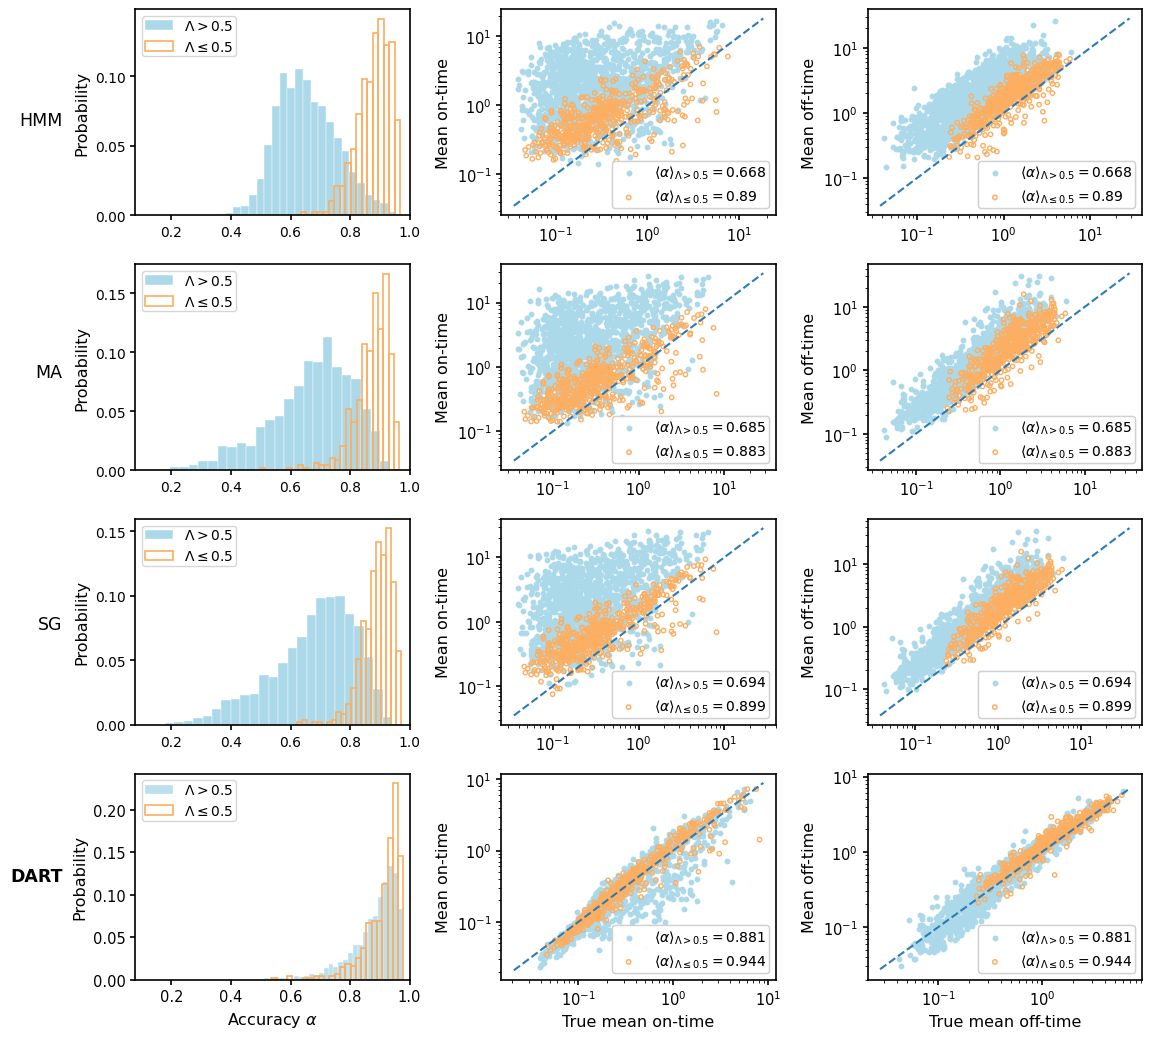

In [78]:
rn_mets = [rn_met_hmm, rn_met_ma, rn_met_sg]
titles = ["HMM", "MA", "SG"];

fig = plot_comparison(onx_scatter, ony_scatter, offx_scatter, offy_scatter, rn_acc_dl, rn_mets, titles, 0.5);

row_labels = ["HMM", "MA", "SG", "DART"]
for (i, label) in enumerate(row_labels)
    ypos = 0.88 - (i-1)*0.24   # adjust spacing depending on your layout
    if label == "DART"
        fig.text(0.005, ypos, label, fontsize=12.5, va="center", ha = "right", fontweight="semibold", fontfamily="Arial")
    else
        fig.text(0.005, ypos, label, fontsize=12.5, va="center", ha = "right", fontfamily="Arial")
    end
end

In [79]:
fig.savefig("figs/compare_all.pdf", bbox_inches="tight", dpi=300)

#### R^2 calculations

In [6]:
#### correlation calculations
hmm_trues = [m.truet_mean for m in rn_met_hmm]
hmm_vals = [m.binart_mean for m in rn_met_hmm];

ma_trues = [m.truet_mean for m in rn_met_ma]
ma_vals = [m.binart_mean for m in rn_met_ma];

sg_trues = [m.truet_mean for m in rn_met_sg]
sg_vals = [m.binart_mean for m in rn_met_sg];

In [7]:
fit_line(map(x->x[1],hmm_trues),map(x->x[1],hmm_vals)),fit_line(map(x->x[2],hmm_trues),map(x->x[2],hmm_vals))

((1.3146241926339253, 1.6360000759963016, 0.16652946439366922), (1.5469434272070897, 1.0637340689239052, 0.34514613300482744))

In [8]:
fit_line(map(x->x[1],ma_trues),map(x->x[1],ma_vals)),fit_line(map(x->x[2],ma_trues),map(x->x[2],ma_vals))

((1.9018210607624542, 1.9767524199692303, 0.16441982042349346), (2.3108955456660643, 0.4278353045325254, 0.4829903357345223))

In [9]:
fit_line(map(x->x[1],sg_trues),map(x->x[1],sg_vals)),fit_line(map(x->x[2],sg_trues),map(x->x[2],sg_vals))

((2.0618264498803125, 1.8359195823794994, 0.20081478372438666), (2.3040293560810077, 0.3758368588001235, 0.4958195804393557))

In [10]:
fit_line(onx_scatter,ony_scatter),fit_line(offx_scatter,offy_scatter)

((0.9271284011190102, 0.029896101109638806, 0.8152359071730335), (1.0829474114149766, 0.05402495412410868, 0.9423051069447825))